Kai Gandingco (kcg2279) <br>
COE 311K <br>
31 March 2026 <br>
# Midterm Project

## Introduction

In this project, I analyze the quarterly growth rate of the U.S's GDP, from the first quarter of 2010 through the fourth quarter of 2023. Specifically, the provided growth rate is the seasonally adjusted annual rate (SAAR) of real GDP growth, in percent, and the given dataset includes 20 selected quarters, with each quarter being represented by consecutive integer indices. The source of this dataset is the U.S. Bureau of Economic Analysis (BEA), and the dataset will be analyzed using three methods: cubic spline interpolation, polynomial fitting, and linear least squares approximation.

Cubic spline interpolation represents a dataset with a smooth curve through every data point by fitting piecewise cubic polynomials on each interval between consecutive data points. Polynomial fitting, in contrast, does not necessarily pass through every data point, but it approximates a dataset using a single polynomial, where the chosen coefficients minimize the squared error between the data and the polynomial. Similarly, linear least squares approximation represents the data by minimizing squared error, in order to choose an appropriate slope and y-intercept, but, as the name suggests, it assumes a linear model for its approximation.

In [174]:
# Kai Gandingco (kcg2279)
# COE 311K
# 31 March 2026
# 
# Midterm Project

import numpy as np
import matplotlib.pyplot as plt
import time

# Given Dataset for U.S. GDP Growth Rate (Quarterly, 2010-2023)
x_subset = np.arange(1, 21) # Selected quarters alone
x_full = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 41, 
                   42, 43, 45, 49, 54, 56]) # Selected quarters in the full context
                 # Final index is 56 here because shouldn't there be 56
                 # quarters from 2010 Q1 to 2023 Q4? 14 years * 4 quarters...
                 # Never mind, I'm probably overthinking this
y_subset = np.array([1.7, 0.1, 2.3,  2.7,   1.7,  5.0, 3.0,  1.5, 3.5, 1.8,
                     1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])
xeval_subset = np.linspace(1, 20, 200)
xeval_full = np.linspace(1, 56, 560)

In [175]:
# Part A - Cubic Spline Interpolation

# Function definitions

def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)  # h = step sizes between data points

    # Initializes the tridiagonal matrix coefficients

    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector

    # Populates the tridiagonal matrix coefficients

    for i in range(1, n - 1):

        A[i - 1] = h[i-1]              # Subdiagonal, A[i] = h_i−1
        B[i - 1] = 2 * (h[i-1] + h[i]) # Main diagonal, B[i] = 2 (h_i-1 + h_i)
        C[i - 1] = h[i]                # Superdiagonal, C[i] = h_i
        D[i - 1] = 6 * ( ((y[i+1]-y[i]) / h[i]) - ((y[i]-y[i-1]) / h[i-1]) )             
        # Right-hand side vector

    return A, B, C, D

# Solves tridiagonal matrix using Thomas Algorithmn
def thomas_algorithm(a, b, c, d):
    n = len(b)
    for i in range (1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
        
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

def evaluate_spline(x, y, M, xeval):
    n = len(x)
    
    for i in range(n - 1):
        if x[i] <= xeval <= x[i+1]:
            h = x[i+1] - x[i]
            a = y[i]
            b = ((y[i+1] - y[i]) / h) - (h * (2*M[i] + M[i+1]) / 6)
            c = M[i] / 2
            d = (M[i+1] - M[i]) / (6 * h)
            
            xdiff = xeval - x[i]
            polynomial = a + b*xdiff + c*(xdiff**2) + d*(xdiff**3)
            return polynomial

Quarter Index:  1
Spline Approximation:  1.7

Quarter Index:  2
Spline Approximation:  0.10000000000000009

Quarter Index:  3
Spline Approximation:  2.3

Quarter Index:  4
Spline Approximation:  2.6999999999999997

Quarter Index:  5
Spline Approximation:  1.7000000000000002

Quarter Index:  6
Spline Approximation:  4.999999999999998

Quarter Index:  7
Spline Approximation:  2.9999999999999996

Quarter Index:  8
Spline Approximation:  1.5000000000000002

Quarter Index:  9
Spline Approximation:  3.5000000000000004

Quarter Index:  10
Spline Approximation:  1.8000000000000005

Quarter Index:  11
Spline Approximation:  1.3000000000000003

Quarter Index:  12
Spline Approximation:  2.5

Quarter Index:  13
Spline Approximation:  3.0999999999999996

Quarter Index:  14
Spline Approximation:  -5.099999999999998

Quarter Index:  15
Spline Approximation:  -28.1

Quarter Index:  16
Spline Approximation:  33.8

Quarter Index:  17
Spline Approximation:  6.300000000000011

Quarter Index:  18
Spline Ap

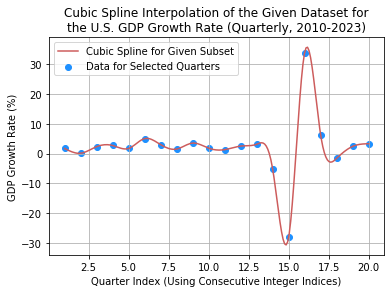

In [176]:
# Part A, Question 1

start_spline = time.perf_counter()
# Sets up the tridiagonal matrix for the cubic spline
A, B, C, D = setup_tridiagonal_matrix(x_subset, y_subset)

# Solves the system with the Thomas algorithm
thomasSolution = thomas_algorithm(A.copy(), B.copy(), C.copy(), D.copy())

# Imposes natural boundary conditions
M = np.zeros(len(x_subset))
M[1:-1] = thomasSolution

# Gets smooth cubic spline
y_spline_smooth = np.array([evaluate_spline(x_subset, y_subset, M, xe) for xe in xeval_subset])
time_spline = time.perf_counter() - start_spline

# Output: Printing and plotting to visualize and check accuracy
for i in range(1, 21):
    print("Quarter Index: ", i)
    print("Spline Approximation: ", evaluate_spline(x_subset, y_subset, M, i))
    print()

plt.figure()
plt.scatter(x_subset, y_subset, color='dodgerblue', label='Data for Selected Quarters')
plt.plot(xeval_subset, y_spline_smooth, color='indianred', label="Cubic Spline for Given Subset")
plt.title("Cubic Spline Interpolation of the Given Dataset " + 
          "for\nthe U.S. GDP Growth Rate (Quarterly, 2010-2023)")
plt.xlabel("Quarter Index (Using Consecutive Integer Indices)")
plt.ylabel("GDP Growth Rate (%)")
plt.legend()
plt.grid()
plt.show()

## Part A, Question 1

In the system of equations I solve in Part A, Question 1, there are 18
unknowns. This is because, in natural spline interpolation, the first and last data points must have second-derivatives of 0. This ensures smooth and stable transitions at the endpoints and is imposed by the boundary conditions for natural cubic splines. As a result, out of the 20 given data points, only 18 are left with unknown second-derivatives, which are solved for in the system of equations.

Unlike at boundaries, at each interior knot, the spline must satisfy
three conditions: first, the spline must pass through the knot. Second, the first-derivative of the spline must be continuous at the knot. Finally, the second-derivative of the spline must be continuous at the knot. These conditions ensure that, within the endpoints, the curve is smooth and passes through every point in the dataset.

Quarter Index:  1
Spline Approximation:  1.7

Quarter Index:  2
Spline Approximation:  -2.7923262807695677

Quarter Index:  3
Spline Approximation:  -5.647722049231309

Quarter Index:  4
Spline Approximation:  -5.229256793077397

Quarter Index:  5
Spline Approximation:  0.09999999999999787

Quarter Index:  6
Spline Approximation:  -2.959951669999124

Quarter Index:  7
Spline Approximation:  -1.9568338523060755

Quarter Index:  8
Spline Approximation:  0.6247008915400123

Quarter Index:  9
Spline Approximation:  2.3000000000000007

Quarter Index:  10
Spline Approximation:  7.732132960766064

Quarter Index:  11
Spline Approximation:  9.67505745845561

Quarter Index:  12
Spline Approximation:  8.03045322691735

Quarter Index:  13
Spline Approximation:  2.700000000000002

Quarter Index:  14
Spline Approximation:  -0.5685801730651289

Quarter Index:  15
Spline Approximation:  -4.143395981516357

Quarter Index:  16
Spline Approximation:  -4.546513799209409

Quarter Index:  17
Spline Approxim

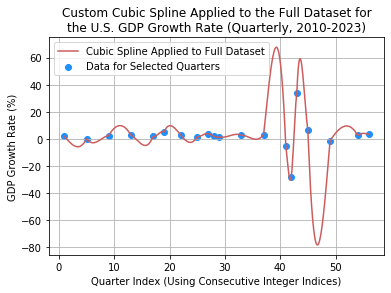

In [177]:
# Part A, Question 2

y_full_smooth = np.array([evaluate_spline(x_full, y_subset, M, xe) for xe in xeval_full])

# Output: Evaluates spline approximation and plots
for i in range(1, 57):
    print("Quarter Index: ", i)
    print("Spline Approximation: ", evaluate_spline(x_full, y_subset, M, i))
    print()

plt.figure()
plt.scatter(x_full, y_subset, color='dodgerblue', label='Data for Selected Quarters')
plt.plot(xeval_full, y_full_smooth, color='indianred', label="Cubic Spline Applied to Full Dataset")
plt.title("Custom Cubic Spline Applied to the Full Dataset " + 
          "for\nthe U.S. GDP Growth Rate (Quarterly, 2010-2023)")
plt.xlabel("Quarter Index (Using Consecutive Integer Indices)")
plt.ylabel("GDP Growth Rate (%)")
plt.legend()
plt.grid()
plt.show()

## Part A, Question 2

After evaluating the spline at every quarter in the full range, the resulting interpolant is visually smooth but is not reasonable. This is due to the COVID-19 pandemic's shock and recovery causing dramatic changes in the GDP, which further leads to extreme oscillations in the spline from 2020 to 2021. In the plot above, this is most apparent around indices 39 to 49. This is indicative of how cubic spline interpolants are sensitive to outliers in data.

## Part A, Question 3

In both plots above, I ensured that the spline passes exactly through the 2020 Q2 value (-28.1%).

The Runge phenomenon results in oscillation at the edges of an interval when using high-degree polynomial interpolation over a set of equispaced points. This phenomenon is significant because it warns against overfitting and exactly interpolating, showing how doing so can result in unstable and inaccurate models. Although exact interpolation is useful when data is recorded with high precision and confidence, it's less stable and extremely sensitive to outliers. In contrast, inexact methods are usually more numerically stable and better for approximation, despite not passing through every point exactly. In this scenario, with the goal of avoiding the Runge phenomenon, smoothing splines is preferable; although weighted least squares regression is useful in mitigating noise in data, it cannot prevent the Runge phenomenon if the global polynomial used in the model is too high. However, smoothing splines avoids this entirely by using piecewise polynomials and prioritizing smoothness over exactness.

In [178]:
# Part B - Polynomial & Least Squares Comparison

# Function definitions

# Custom method to create increasing Vandermonde matrix
def custom_vander(x, N=None, increasing=True):
    x = np.asarray(x)
    if N == None:
        N = len(X)
    
    if increasing:
        columns = [x**i for i in range(N)]
    else:
        columns = [x**(N-1-i) for i in range(N)]
    
    vandermonde = np.vstack(columns).T
    return vandermonde

# Makes Vandermonde matrix (using custom method) and solves for coefficients
def create_vandermonde_matrix(X, Y, degree):
    V = custom_vander(X, N=degree+1, increasing=True)
    VT_V = V.T @ V
    VT_y = V.T @ Y
    a = np.linalg.solve(VT_V, VT_y) # Solves for a (coefficients)
    return V, a

# Minimizes error based on the sum of the squared residuals
def myLeastSquares(x, y):
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_x2 = np.sum(x*x)
    sum_xy = np.sum(x*y)
    mNumerator = len(x) * sum_xy - (sum_x * sum_y)
    mDenominator = len(x) * sum_x2 - (sum_x * sum_x)
    m = mNumerator / mDenominator
    c = (sum_y - m * sum_x) / len(x)
    return m, c

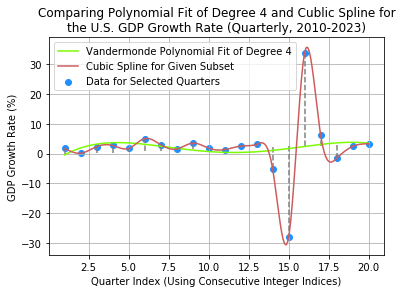

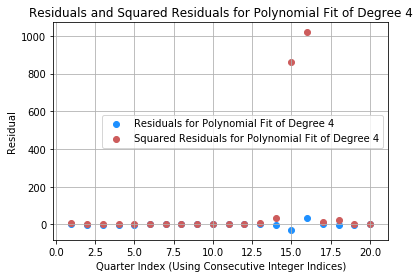

Sum of Squared Residuals: 1987.3496762926711


In [179]:
# Part B, Question 1

start_polyfit = time.perf_counter()
d = 4 # Polynomial of degree 4
V, coefficients = create_vandermonde_matrix(x_subset, y_subset, d)
y_vander = V @ coefficients
V_smoothPlot = custom_vander(xeval_subset, d + 1, increasing=True)
y_vander_smooth = V_smoothPlot @ coefficients
time_polyfit = time.perf_counter() - start_polyfit

# Calculates residuals
polynomial_residuals = y_subset - y_vander_smooth[0:len(y_vander_smooth):int((len(y_vander_smooth) / len(y_subset)))]
polynomial_residuals_squared = polynomial_residuals**2

# Plots the polynomial fit (alongside the cubic spline)
plt.figure()
plt.scatter(x_subset, y_subset, color='dodgerblue', label='Data for Selected Quarters')
plt.plot(xeval_subset, y_vander_smooth, color='lawngreen', label="Vandermonde Polynomial Fit of Degree 4")
plt.vlines(x_subset, y_vander_smooth, y_subset, color='gray', linestyle='dashed')
plt.plot(xeval_subset, y_spline_smooth, color='indianred', label="Cubic Spline for Given Subset")
plt.title("Comparing Polynomial Fit of Degree 4 and Cublic Spline for" + 
          "\nthe U.S. GDP Growth Rate (Quarterly, 2010-2023)")
plt.xlabel("Quarter Index (Using Consecutive Integer Indices)")
plt.ylabel("GDP Growth Rate (%)")
plt.legend()
plt.grid()
plt.show()

# Plots residuals
plt.figure()
plt.scatter(x_subset, polynomial_residuals, color='dodgerblue', label='Residuals for Polynomial Fit of Degree 4')
plt.scatter(x_subset, polynomial_residuals_squared, color='indianred', label='Squared Residuals for Polynomial Fit of Degree 4')
plt.title("Residuals and Squared Residuals for Polynomial Fit of Degree 4")
plt.xlabel("Quarter Index (Using Consecutive Integer Indices)")
plt.ylabel("Residual")
plt.legend()
plt.grid()
plt.show()

print("Sum of Squared Residuals:", np.sum(polynomial_residuals_squared))

## Part B, Question 1

The polynomial fit better captures the overall trend while the cubic spline better reproduces specific data points. The strength of the polynomial fit is illustrated in the plot of its residuals (Residuals and Squared Residuals for Polynomial Fit of Degree 4). In this plot, the points scatter relatively evenly around zero, with the exception of the clear outliers resulting from the COVID-19 pandemic. This suggests that the model is a good fit without overfitting and can be used to reasonably approximate unknown data points. On the other hand, the cubic spline model better reproduces specific data points. This is demonstrated by how the spline passes exactly through the 2020 Q2 value (-28.1%), despite this being an outlier in the dataset. From this, one can conclude that cubic spline interpolation is good for smoothly interpolating between and reproducing known data points but, due to its consideration of outliers, is not suitable for analyzing overall trends.

To summarize, approximation is useful for prediction of trends and minimizes overall error, in a sense looking beyond potential noise and outliers, but it does not pass through all data points; as a result, it does not exactly match data that has already been observed. On the flip side, interpolation is used for exactly reproducing data points and assumes that observed data is noise free. However, in cases of error or noise, interpolation is weaker in identifying trends and may add unnecessary oscillations between data points.

Slope: -0.0173364485981308


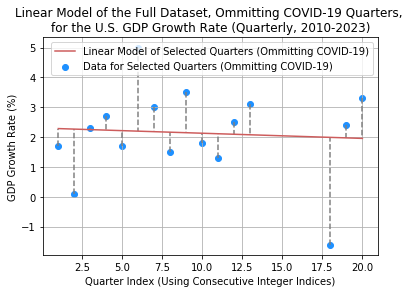

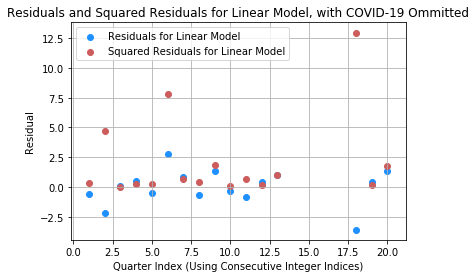

Sum of Squared Residuals with COVID-19 Quarters Ommitted: 33.17857943925233


In [180]:
# Part B, Question 2

# For all code in this, COVID-19 quarters are **ommitted**

# New datasets, excluding the COVID quarters
x_normal_subset = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 18, 19, 20])
y_normal_subset = np.array([1.7, 0.1, 2.3,  2.7, 1.7, 5.0, 3.0,  1.5, 3.5, 1.8,
                     1.3, 2.5, 3.1, -1.6, 2.4, 3.3])

# Determines linear model with COVID quarters excluded
start_linear = time.perf_counter()
A = np.vstack([x_normal_subset, np.ones(len(x_normal_subset))]).T
my_m, my_c = myLeastSquares(x_normal_subset, y_normal_subset)
time_linear = time.perf_counter() - start_linear
print("Slope:", my_m) # Report slope

# Calculates residuals
linear_residuals = y_normal_subset - (my_m * x_normal_subset + my_c)
linear_residuals_squared = linear_residuals**2

# Plots the linear model
plt.figure()
plt.scatter(x_normal_subset, y_normal_subset, color='dodgerblue', label='Data for Selected Quarters (Ommitting COVID-19)')
plt.plot(x_normal_subset, my_m * x_normal_subset + my_c, color='indianred', label='Linear Model of Selected Quarters (Ommitting COVID-19)')
plt.vlines(x_normal_subset, y_normal_subset, my_m * x_normal_subset + my_c, color='gray', linestyle='dashed')
plt.title("Linear Model of the Full Dataset, Ommitting COVID-19 Quarters, " + 
          "\nfor the U.S. GDP Growth Rate (Quarterly, 2010-2023)")
plt.xlabel("Quarter Index (Using Consecutive Integer Indices)")
plt.ylabel("GDP Growth Rate (%)")
plt.legend()
plt.grid()
plt.show()

# Plots the residuals
plt.figure()
plt.scatter(x_normal_subset, linear_residuals, color='dodgerblue', label='Residuals for Linear Model')
plt.scatter(x_normal_subset, linear_residuals_squared, color='indianred', label='Squared Residuals for Linear Model')
plt.title("Residuals and Squared Residuals for Linear Model, with COVID-19 Ommitted")
plt.xlabel("Quarter Index (Using Consecutive Integer Indices)")
plt.ylabel("Residual")
plt.legend()
plt.grid()
plt.show()

print("Sum of Squared Residuals with COVID-19 Quarters Ommitted:", np.sum(linear_residuals_squared))

Slope: 0.045714285714285714


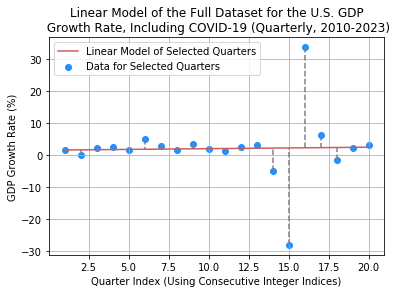

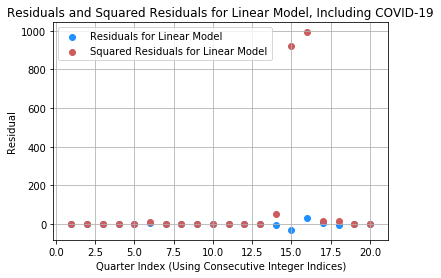

Sum of Squared Residuals, Including COVID-19 Quarters: 2018.3582857142853


In [181]:
# Part B, Question 2

# For all code in this cell, COVID-19 quarters are **included**
# in order to deepen discussion of the effects of COVID exclusion,
# per the grading rubric.

# Determines linear model **including COVID quarters**
A = np.vstack([x_subset, np.ones(len(x_subset))]).T
my_m, my_c = myLeastSquares(x_subset, y_subset)
print("Slope:", my_m) # Report slope

# Calculates residuals
linear_residuals = y_subset - (my_m * x_subset + my_c)
linear_residuals_squared = linear_residuals**2

# Plots the linear model
plt.figure()
plt.scatter(x_subset, y_subset, color='dodgerblue', label='Data for Selected Quarters')
plt.plot(x_subset, my_m * x_subset + my_c, color='indianred', label='Linear Model of Selected Quarters')
plt.vlines(x_subset, y_subset, my_m * x_subset + my_c, color='gray', linestyle='dashed')
plt.title("Linear Model of the Full Dataset " + 
          "for the U.S. GDP\n Growth Rate, Including COVID-19 (Quarterly, 2010-2023)")
plt.xlabel("Quarter Index (Using Consecutive Integer Indices)")
plt.ylabel("GDP Growth Rate (%)")
plt.legend()
plt.grid()
plt.show()

# Plots the residuals
plt.figure()
plt.scatter(x_subset, linear_residuals, color='dodgerblue', label='Residuals for Linear Model')
plt.scatter(x_subset, linear_residuals_squared, color='indianred', label='Squared Residuals for Linear Model')
plt.title("Residuals and Squared Residuals for Linear Model, Including COVID-19")
plt.xlabel("Quarter Index (Using Consecutive Integer Indices)")
plt.ylabel("Residual")
plt.legend()
plt.grid()
plt.show()

print("Sum of Squared Residuals, Including COVID-19 Quarters:", np.sum(linear_residuals_squared))

## Part B, Question 2

Although a linear least squares regression somewhat makes graphical sense for this data, it does not make economic sense because the economy, especially the U.S.'s developed economy, follows the business cycle, with natural periods of expansion and recession. A strictly linear trend does not account for this cyclical behavior and instead assumes that the economy's GDP growth rate will change at a constant rate over time.

With a linear model, excluding the quarters that occurred during the COVID-19 pandemic is significant because it reduces the impact of outliers on the slope. Even though the effect of the pandemic on the economy was a period of temporary shock followed by recovery, including those quarters would impact the entire model. To illustrate this distortion, I plotted two linear models: one with the quarters that occurred during the COVID-19 pandemic and one without. This resulted in a clear difference; the linear model that included COVID-19 had a slope of 0.0457% per quarter while the linear model that excluded COVID-19 had a slope of -0.0173% per quarter.

In [182]:
# Part C - Method Justification

# Comparing cubic spline interpolation and polynomial fit 
# (with a degree of 4) by finding RMSE

# RMSE for cubic spline interpolation
y_spline = np.array([evaluate_spline(x_subset, y_subset, M, x) for x in x_subset])
mse_spline = np.mean((y_subset - y_spline)**2)
rmse_spline = np.sqrt(mse_spline)
print("Root Mean Square Error, in %, for Cubic Spline Interpolation:", rmse_spline)

# RMSE for polynomial fit
mse_polyfit = np.mean((y_subset - y_vander)**2)
rmse_polyfit = np.sqrt(mse_polyfit)
print("Root Mean Square Error, in %, for 4th Degree Polynomial Fit:", rmse_polyfit)

Root Mean Square Error, in %, for Cubic Spline Interpolation: 2.8707974391483537e-15
Root Mean Square Error, in %, for 4th Degree Polynomial Fit: 9.965326786519526


## Part C, Method Justification

To estimate GDP growth for a quarter between two known data points, I would recommend cubic spline interpolation. This is because, in terms of accuracy and sensitivity to outliers, cubic spline interpolation will be more locally accurate than a single polynomial fit. A global polynomial fit may be distorted by outliers outside the two known points, meaning the fit will not be specific to the quarter in question. Although this may be useful for identifying and predicting overall trends, this lack of isolation leaves more room for error locally, which is not helpful for estimating the GDP growth rate of a single quarter. In contrast, with cubic spline interpolation, outliers only affect the interval in which they occur, limiting their influence on the rest of the curve. In addition, due to its precision and piecewise nature, cubic spline interpolation is very faithful to known data, aligning with the two known data points surrounding the quarter in question.

In terms of smoothness, cubic spline interpolation guarantees smoothness by returning a piecewise cubic function specific to each interval. By nature, this function is also continuous across intervals, resulting in smooth transitions between the quarters of the two known points and the quarter in question.

Additionally, to justify this method quantitatively, I calculated the RMSE for each method. RMSE, or Root Mean Square Error, measures the average difference between actual and predicted values. RMSE penalizes larger errors more heavily than smaller ones and expresses error in the same units as the data, making it more interpretable than regular Mean Square Error (MSE). For cubic spline interpolation, the RMSE was 2.87e-15, meaning that the error was effectively zero. In contrast, the RMSE for the 4th degree polynomial fit was 9.97. This reflects the strength of cubic spline interpolation's precision and accuracy regarding individual data points, certainly making it a stronger method for estimating the GDP growth during a quarter between two known data points.

## Part C, Big O Addendum

Big O Notation is a mathematical tool that evaluates the efficiency of an algorithm based on its time and/or space growth rate as input size increases. For cubic spline interpolation, the Big O notation is generally *O(n)*, where *n* is the number of data points. This is because the cubic spline interpolation method involves solving a tridiagonal matrix, which is solved efficiently using the Thomas algorithm. The time this takes is directly proportional to the number of data points, resulting in a linear relationship between input size and time. For polynomial fitting, the Big O notation depends on both the degree *m* of the polynomial and the number of data points, *n*. This results in a Big O notation of *O(nm^2)*, where the time this method takes grows quadratically with the degree of the polynomial, indicating that high-degree polynomial fitting is inefficient. Finally, the Big O notation for my implementation of linear least squares regression is *O(n)* because my implementation simply reads all data points.

The Big O notations of the different algorithms reinforces my recommendation. Not only will cubic spline interpolation more accurately estimate the GDP growth for a specific quarter between two known data points, but it is also an efficient algorithm no matter the input size. It also does not require consideration of other factors, unlike how the degree of the polynomial must be taken into account to determine the Big O notation for polynomial fitting.

## Conclusion

To summarize my conclusions from this project, I've determined that cubic spline interpolation is a strong method for interpolating specific data points within well-defined intervals, or intervals with known data points as endpoints. However, it is not without its drawbacks: intervals containing outliers are more likely to illustrate inaccurate oscillations, although such behavior will largely be restricted to those specific intervals. In contrast, polynomial fitting is better for trend analysis, but its drawback is that error caused by outliers affects the entire model, rather than being restricted to a specific interval. Additionally, in order to represent the entire dataset effectively, a polynomial fit rarely passes through each data point exactly. Finally, linear least squares regression, while appearing to at least be somewhat graphically accurate, does not fully reflect the cyclical nature of the dataset as a representation of the U.S. economy.